# Technical AI Workshop – Session 1  
## Representing and Comparing Documents

### Central Question
> “We have documents—how can we represent them so we can tell which ones are similar and which ones are different?”

Imagine a bunch of short texts or emails:
- Some talk about **sports**
- Some about **medicine**
- Some about **technology**

We want to answer:
- Which documents are about the same topic?
- Which are completely unrelated?

---

### Step 1: Representing Documents
Students will brainstorm:
- Could we write rules?
- Could we use human intuition?

Rule-based approaches are messy. Let's try **automatic counting**:
- Count which words appear in each document
- Keep words that are **meaningful** for the topic

> Example:
> - **Sports:** `baseball`, `pitcher`, `hockey`, `goal`, `team`  
> - **Medical:** `cancer`, `doctor`, `treatment`, `patients`  
> - **Technology:** `windows`, `linux`, `program`, `software`

This gives a **concrete representation** of each document as a list of numbers.

---

### Step 2: Comparing Documents
Once represented as numbers:
- Documents with many of the same words → more similar
- Documents with completely different words → very different

> Conceptually, each document is a “bag of words” or a “list of numbers”.  
> We can measure similarity by **how much they overlap**.

---

### Step 3: Big Picture
Students will understand:
1. **Representation:** Transform raw data into a form computers can compare
2. **Similarity:** Measure relatedness by comparing representations

> Next: visualize document similarity with simple examples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style="white")

# Load a small subset of 20 newsgroups
categories = [
    "comp.windows.x",
    "rec.sport.baseball",
    "rec.sport.hockey",
    "sci.med",
]

newsgroups = fetch_20newsgroups(
    subset="all",
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
    categories=categories,
)

df = pd.DataFrame({"text": newsgroups.data, "target": newsgroups.target})
target_names = newsgroups.target_names

# Sort by target to group similar topics together
sorted_indices = np.argsort(df["target"])
X_sorted = df["text"].iloc[sorted_indices].reset_index(drop=True)
y_sorted = df["target"].iloc[sorted_indices].reset_index(drop=True)

print(f"Documents: {len(X_sorted)}")
print("Topics:", target_names)

Documents: 3971
Topics: ['comp.windows.x', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.med']


## Baseline: use all the words we can

We start with a simple representation: let the computer turn each document into a list of numbers using the words it sees.

This is our baseline. It is intentionally broad, so students can see the raw structure before we simplify anything.

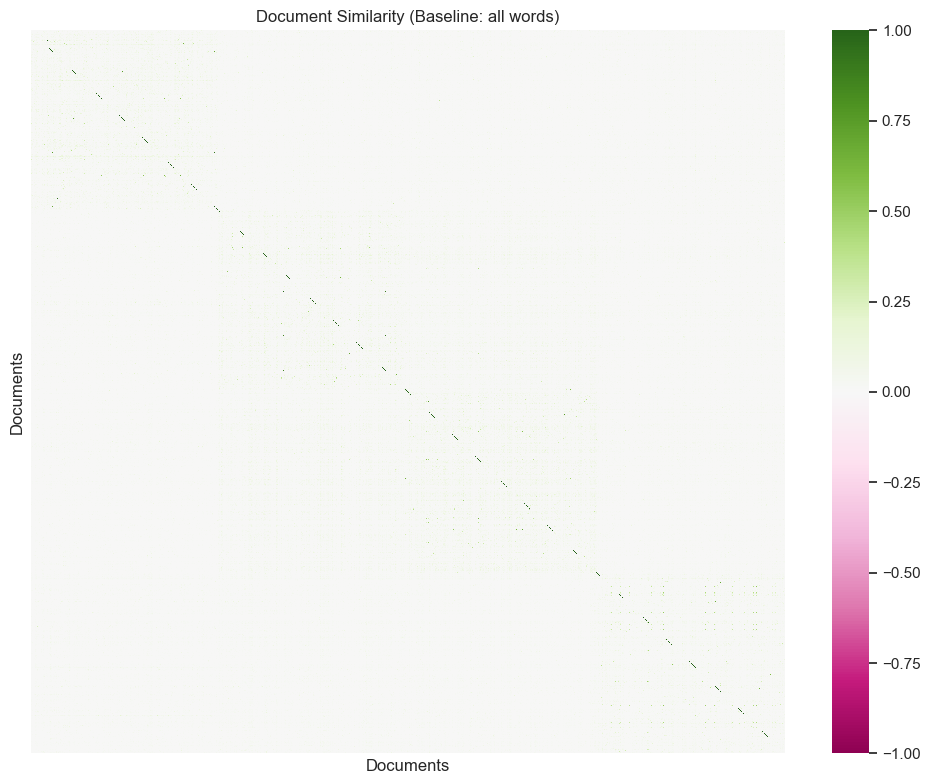

In [ ]:
def plot_similarity_heatmap(X, title):
    cos_sim = cosine_similarity(X)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cos_sim,
        cmap="PiYG",   # white = 0, black = 1
        vmin=0,
        vmax=1,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
    )
    plt.title(title)
    plt.xlabel("Documents")
    plt.ylabel("Documents")
    plt.tight_layout()
    plt.show()
    return cos_sim

vectorizer_basic = TfidfVectorizer(stop_words="english")
X_basic = vectorizer_basic.fit_transform(X_sorted)
cos_sim_basic = plot_similarity_heatmap(
    X_basic,
    "Document Similarity (Baseline: all words)"
)

## A more controlled vocabulary

We can now reduce noise by keeping only words that appear often enough, but not too often.

This is a useful baseline, but in practice it often changes the picture only a little.  
That is already a good lesson: not every filtering trick creates a dramatic visual difference.

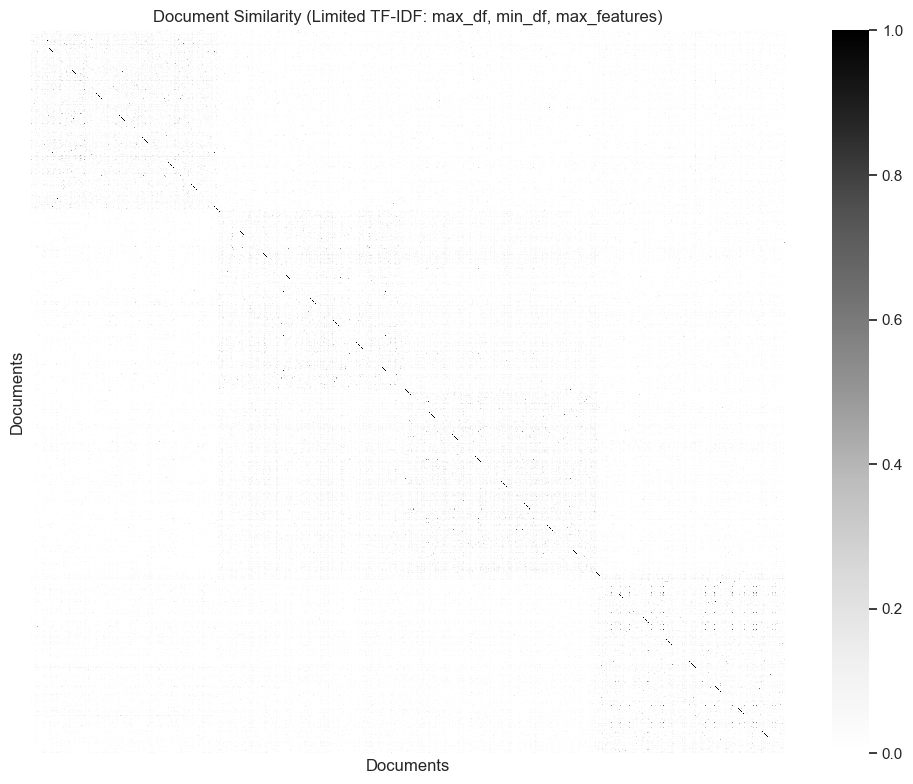

In [15]:
vectorizer_limited = TfidfVectorizer(
    stop_words="english",
    max_df=0.5,
    min_df=5,
    max_features=5000,
)

X_limited = vectorizer_limited.fit_transform(X_sorted)
cos_sim_limited = plot_similarity_heatmap(
    X_limited,
    "Document Similarity (Limited TF-IDF: max_df, min_df, max_features)"
)

## A more human-friendly representation

Instead of relying only on automatic filtering, we can also choose a small set of words that make sense to us.

This is the version that makes the story easiest to explain:
- sports words
- medical words
- technology words

The goal is not to build the best model.  
The goal is to make the idea of **representation** visible.

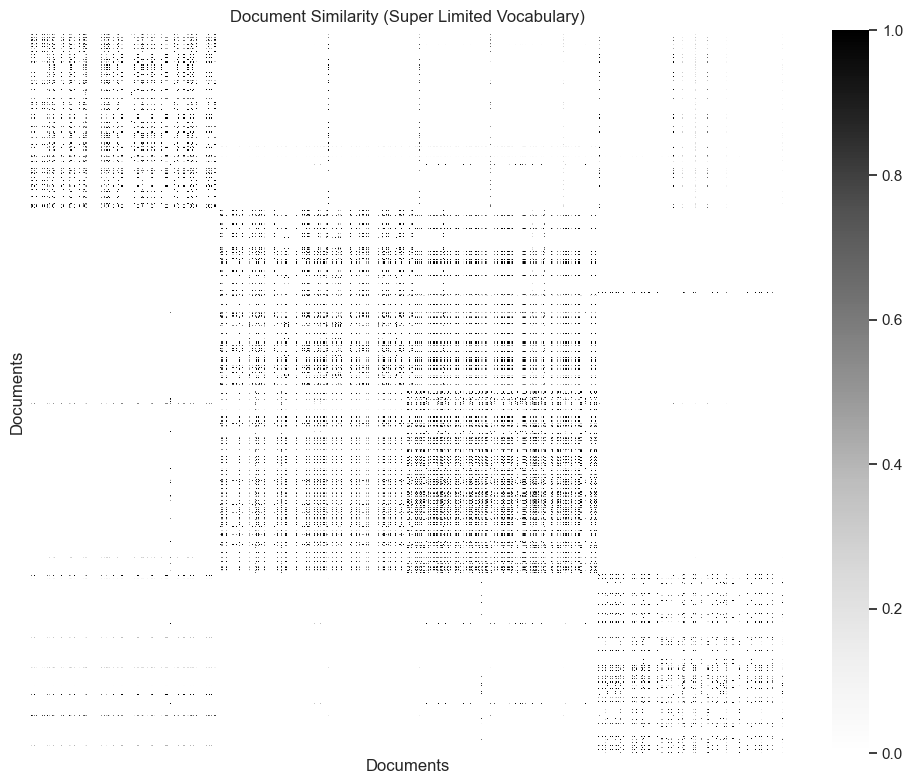

In [16]:
sports_words = [
    "baseball", "pitch", "hockey", "goal", "team"
]

medical_words = [
    "cancer", "doctor", "treatment", "disease"
]

tech_words = [
    "windows", "linux", "file", "program"
]

vocab = sports_words + medical_words + tech_words

vectorizer_super_limited = TfidfVectorizer(
    stop_words="english",
    vocabulary=vocab,
)

X_super_limited = vectorizer_super_limited.fit_transform(X_sorted)
cos_sim_super_limited = plot_similarity_heatmap(
    X_super_limited,
    "Document Similarity (Super Limited Vocabulary)"
)

## Final remarks

What did we learn?

1. A document can be turned into a numerical representation.
2. Similar documents tend to get similar representations.
3. Cosine similarity gives us a simple way to compare those representations.
4. Automatic filtering can help a little, but the biggest gain here comes from choosing words that match the meaning we care about.

The main teaching message is simple:

> Good representations make similarity easier to see.

In the next step, students can experiment by changing the vocabulary and seeing how the heatmap changes.